<a href="https://colab.research.google.com/github/dhruvcshekar/AI-Credit-Risk-Engine/blob/main/Copy_of_AI_credit_score_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('heloc_dataset_v1 (1).csv')

In [ ]:
np.random.seed(42)
n_rows = len(df)

3. Handle Negative Values

In [ ]:
risk_clean = df['ExternalRiskEstimate'].copy()

 Replace FICO missing codes (-9, -8, -7) with the median

In [ ]:
median_val = risk_clean[risk_clean >= 0].median()
risk_clean[risk_clean < 0] = median_val

4. Create the new features

Utility Consistency

In [ ]:
base_consistency = (risk_clean - risk_clean.min()) / (risk_clean.max() - risk_clean.min())
noise = np.random.normal(0, 0.05, n_rows)
df['Utility_Consistency_Score'] = (base_consistency + noise).clip(0, 1)

Gig Volatility


In [ ]:
volatility_base = 1000 - (base_consistency * 500)
df['Gig_Income_Volatility'] = np.random.gamma(shape=2.0, scale=volatility_base/2, size=n_rows)

Subscription plans

In [ ]:
burden_base = 0.10 - (base_consistency * 0.05)
df['Subscription_Burden'] = (burden_base + np.random.uniform(0, 0.05, n_rows)).clip(0.01, 0.20)

In [ ]:
print("Features created successfully!")
print(df[['ExternalRiskEstimate', 'Utility_Consistency_Score']].head())

Features created successfully!
   ExternalRiskEstimate  Utility_Consistency_Score
0                    55                   0.385491
1                    61                   0.452103
2                    67                   0.589761
3                    66                   0.617135
4                    81                   0.775178


# **STEP 2**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

 1. Convert Target to Binary (Bad = 1, Good = 0)

In [ ]:
df['target'] = df['RiskPerformance'].map({'Bad': 1, 'Good': 0})

2. Define Features (X) and Target (y)

In [ ]:
# We drop the original string target and the temporary 'target' column
X = df.drop(['RiskPerformance', 'target'], axis=1)
y = df['target']

3. Split into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Apply Monotonic Constraints

In [ ]:
# This is the "Finance Special." 1 means 'Must Increase', -1 means 'Must Decrease'
# For example: As ExternalRiskEstimate increases, Probability of Default (Bad) should decrease (-1)
constraints = []
for col in X.columns:
    if col in ['ExternalRiskEstimate', 'Utility_Consistency_Score', 'NumSatisfactoryTrades']:
        constraints.append(-1) # Higher value = Lower risk
    elif col in ['Gig_Income_Volatility', 'Subscription_Burden', 'NetFractionRevolvingBurden']:
        constraints.append(1)  # Higher value = Higher risk
    else:
        constraints.append(0)  # No constraint

5. Train the Model

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    monotone_constraints=tuple(constraints),
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan,
              monotone_constraints=(-1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                                    0, 0, 0, 1, 0, 0, 0, 0, 0, -1, 1, 1),
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

6. Evaluate

In [ ]:
y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"Model Training Complete!")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nModel logic is now constrained for regulatory approval.")

Model Training Complete!
ROC-AUC Score: 0.7787

Model logic is now constrained for regulatory approval.


#**Utilizing SHAP to show reason**

In [ ]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt

1. Initialize the SHAP explainer

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

2. Global Explainability: What matters most to the model overall?

Generating Global Feature Importance...


/tmp/ipykernel_21743/3247574254.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


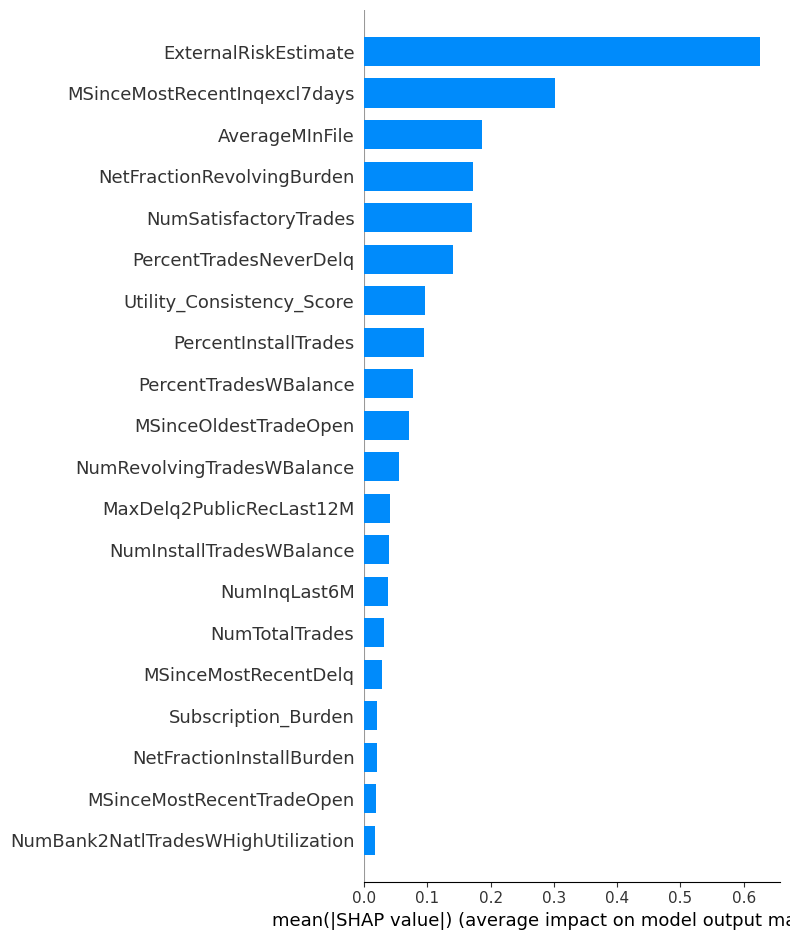

In [ ]:
print("Generating Global Feature Importance...")
shap.summary_plot(shap_values, X_test, plot_type="bar")

3. Local Explainability: Why was a SPECIFIC person rejected?

In [ ]:
# Picking the first person in the test set who the model predicted as high risk.
high_risk_idx = 0
sample_data = X_test.iloc[high_risk_idx : high_risk_idx + 1]
individual_shap_values = explainer(sample_data)

4. Visualize the "Reason Codes" for this person


Individual Analysis for Customer at index 7528:


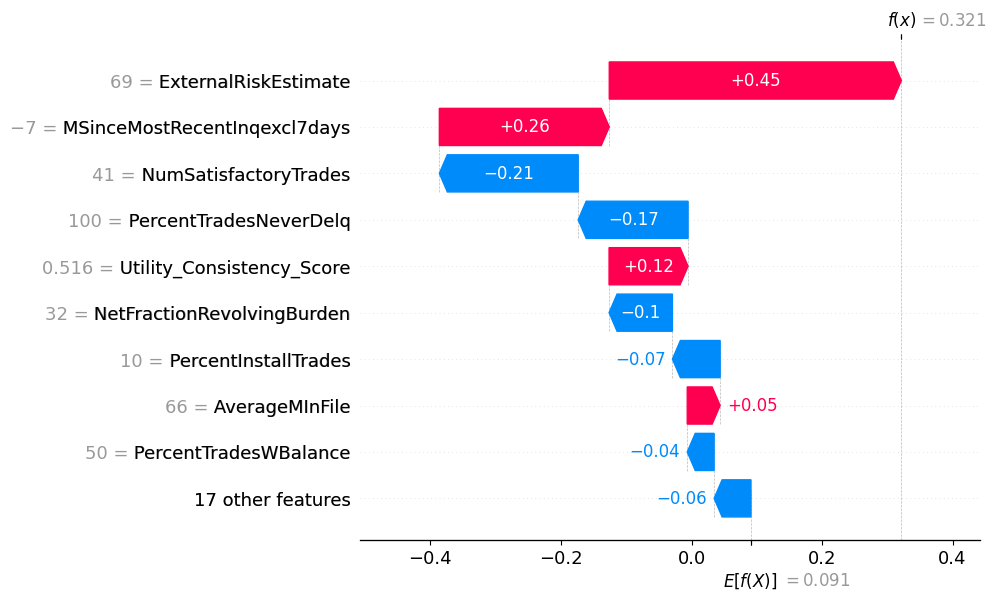

In [ ]:
print(f"\nIndividual Analysis for Customer at index {X_test.index[high_risk_idx]}:")
shap.plots.waterfall(individual_shap_values[0])

5. Mapping to Human-Readable Reason Codes

In [ ]:
# We look at the top 3 features that pushed the score towards '1' (Bad)
feature_impacts = pd.Series(individual_shap_values.values[0], index=X_test.columns)
top_reasons = feature_impacts.sort_values(ascending=False).head(3)

In [ ]:
print("\n--- AUTOMATED ADVERSE ACTION REASONS ---")
for i, (feature, impact) in enumerate(top_reasons.items(), 1):
    val = sample_data[feature].values[0]
    print(f"Reason {i}: {feature} (Value: {val}) increased risk score by {impact:.4f}")


--- AUTOMATED ADVERSE ACTION REASONS ---
Reason 1: ExternalRiskEstimate (Value: 69) increased risk score by 0.4475
Reason 2: MSinceMostRecentInqexcl7days (Value: -7) increased risk score by 0.2603
Reason 3: Utility_Consistency_Score (Value: 0.5159046262912329) increased risk score by 0.1210


#And Finally check for Bias

In [ ]:
# Quick fairness check: Do people with low vs high risk estimates get drastically different explanations?
df_test = X_test.copy()
df_test['pred'] = y_pred

# Create a 'Low Estimate' group (below median)
median_est = df_test['ExternalRiskEstimate'].median()
low_est_group = df_test[df_test['ExternalRiskEstimate'] < median_est]
high_est_group = df_test[df_test['ExternalRiskEstimate'] >= median_est]

print(f"Average Default Risk (Low Estimate Group): {low_est_group['pred'].mean():.2%}")
print(f"Average Default Risk (High Estimate Group): {high_est_group['pred'].mean():.2%}")

Average Default Risk (Low Estimate Group): 73.35%
Average Default Risk (High Estimate Group): 31.18%
